
### Two-Photon Absorption Data Analysis 

        Sean Keenan, PhD Physics  
        Quantum Memories Group, Heriot-Watt University, Edinburgh  
        2023

In [69]:
#matplotlib widget
import data_funcs as df
from filter_funcs import smooth_data
from math_funcs import normalise, OD_calc
import matplotlib.pyplot as mp
import numpy as np
import os
from plotting_funcs import plot_scope
from scipy.integrate import simpson

mp.style.use('signature.mplstyle')


##### Set Directory and Args
        
        Define the directory to extract files from and provide discriminators


In [2]:
directory = r'C:\Users\sk88\Dropbox (Heriot-Watt University Team)\RES_EPS_Quantum_Photonics_Lab\Experiments\Current Experiments\BB Telecom QM\2023_PrYSO_Spectroscopy'
folder = '2212_TPA'

path = os.path.join(directory, folder)

exts = ('.csv')
exceptions = ['.png', 'avg']
refs_995 = ['995_solo']
refs_1550 = ['1550_solo']
refs = refs_995 + refs_1550
# polarisation for maximum and minimum absorption of both 1550 and 995 pulses
polarisation_1550 = ['105', '145']
polarisation_995 = ['40', '350']


##### Import Data  
        
        Extract folder and file name pairs and assemble paths to data before extracting files


In [3]:
# interogate directory to extract folder and file names
folder_list, file_list = df.dir_interogate(path, exts, exceptions)
# assemble reference paths
ref_995_path = df.search_paths(folder_list, file_list, include=refs_995)
ref_1550_path = df.search_paths(folder_list, file_list, include=refs_1550)
ref_995_path_list = [os.path.join(path, x) for x in ref_995_path]
ref_1550_path_list = [os.path.join(path, x) for x in ref_1550_path]
# find polarisation numbers from reference file names
polarisations_995 = [df.find_numbers(os.path.split(path)[1], '\d+') for path in ref_995_path]
polarisations_1550 = [df.find_numbers(os.path.split(path)[1], '\d+') for path in ref_1550_path]
# assemble TPA paths
tpa_paths_995_fix = df.search_paths(folder_list, file_list, include=['995_HWP'], exclude=refs)
tpa_paths_1550_fix = df.search_paths(folder_list, file_list, include=['1550_HWP'], exclude=refs)
# reference excel data
ref_995_excel_data = np.asarray([df.open_excel(os.path.join(path, x)) for x in ref_995_path])
ref_1550_excel_data = np.asarray([df.open_excel(os.path.join(path, x)) for x in ref_1550_path])
# separate 1550 and 995 excel data
tpa_excel_data_995_fix = np.asarray([[df.open_excel(os.path.join(path, x)) for x in tpa_path] for tpa_path in tpa_paths_995_fix])
tpa_excel_data_1550_fix = np.asarray([[df.open_excel(os.path.join(path, x))  for x in tpa_path] for tpa_path in tpa_paths_1550_fix])


##### Organise Data  
        
        Separate various sets into channels 


In [4]:
# separate control pulse excel data
ref_995_time_data = [excel_data[:,0] for excel_data in ref_995_excel_data]
ref_995_1550_pulse_data = [excel_data[:,1] for excel_data in ref_995_excel_data]
ref_995_1550_ref_data = [excel_data[:,2] for excel_data in ref_995_excel_data]
ref_995_995_pulse_data = [excel_data[:,3] for excel_data in ref_995_excel_data]
ref_995_995_ref_data = [excel_data[:,4] for excel_data in ref_995_excel_data]
# separate storage pulse excel data
ref_1550_time_data = [excel_data[:,0] for excel_data in ref_1550_excel_data]
ref_1550_1550_pulse_data = [excel_data[:,1] for excel_data in ref_1550_excel_data]
ref_1550_1550_ref_data = [excel_data[:,2] for excel_data in ref_1550_excel_data]
ref_1550_995_pulse_data = [excel_data[:,3] for excel_data in ref_1550_excel_data]
ref_1550_995_ref_data = [excel_data[:,4] for excel_data in ref_1550_excel_data]
# separate TPA excel data for 995 measurements
tpa_time_data_995_fix = [[excel_data[:,0] for excel_data in folder_data] for folder_data in tpa_excel_data_995_fix]
tpa_1550_pulse_data_995_fix = [[excel_data[:,1] for excel_data in folder_data] for folder_data in tpa_excel_data_995_fix]
tpa_1550_ref_data_995_fix = [[excel_data[:,2] for excel_data in folder_data] for folder_data in tpa_excel_data_995_fix]
tpa_995_pulse_data_995_fix = [[excel_data[:,3] for excel_data in folder_data] for folder_data in tpa_excel_data_995_fix]
tpa_995_ref_data_995_fix = [[excel_data[:,4] for excel_data in folder_data] for folder_data in tpa_excel_data_995_fix]
# separate TPA excel data for 1550 measurements
tpa_time_data_1550_fix = [[excel_data[:,0] for excel_data in folder_data] for folder_data in tpa_excel_data_1550_fix]
tpa_1550_pulse_data_1550_fix = [[excel_data[:,1] for excel_data in folder_data] for folder_data in tpa_excel_data_1550_fix]
tpa_1550_ref_data_1550_fix = [[excel_data[:,2] for excel_data in folder_data] for folder_data in tpa_excel_data_1550_fix]
tpa_995_pulse_data_1550_fix  = [[excel_data[:,3] for excel_data in folder_data] for folder_data in tpa_excel_data_1550_fix]
tpa_995_ref_data_1550_fix  = [[excel_data[:,4] for excel_data in folder_data] for folder_data in tpa_excel_data_1550_fix]
# find hwp index for maximum and minimum absorption
max_995_abs = [i for files in file_list for i, x in enumerate(files) if df.check_str(polarisation_995[0], x)][0]
min_995_abs = [i for files in file_list for i, x in enumerate(files) if df.check_str(polarisation_995[1], x)][0]
max_1550_abs = [i for files in file_list for i, x in enumerate(files) if df.check_str(polarisation_1550[0], x)][0]
min_1550_abs = [i for files in file_list for i, x in enumerate(files) if df.check_str(polarisation_1550[1], x)][0]
max_995_fix_abs = [i for i, files in enumerate(tpa_paths_995_fix) for x in files if polarisation_995[0] in x][0]
min_995_fix_abs = [i for i, files in enumerate(tpa_paths_995_fix) for x in files if polarisation_995[1] in x][0]
max_1550_fix_abs = [i for i, files in enumerate(tpa_paths_1550_fix) for x in files if polarisation_1550[0] in x][0]
min_1550_fix_abs = [i for i, files in enumerate(tpa_paths_1550_fix) for x in files if polarisation_1550[1] in x][0]
index_995_abs = [min_995_abs, max_995_abs]
index_1550_abs = [min_1550_abs, max_1550_abs]
index_995_fix_abs = [min_995_fix_abs, max_995_fix_abs]
index_1550_fix_abs = [min_1550_fix_abs, max_1550_fix_abs]


##### Plot sets to check assignment 
        
        Plot the channels for a subset of folders to check channel assignment


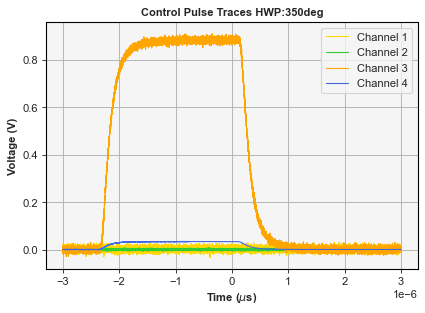

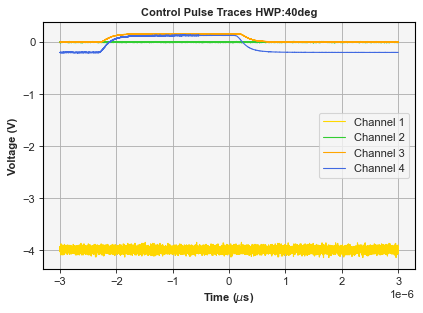

In [5]:
for index in index_995_abs:
    plot_scope(ref_995_time_data[index], [ref_995_1550_pulse_data[index], ref_995_1550_ref_data[index], ref_995_995_pulse_data[index], ref_995_995_ref_data[index]])
    mp.title('Control Pulse Traces' + ' HWP:' + polarisations_995[index] + 'deg')

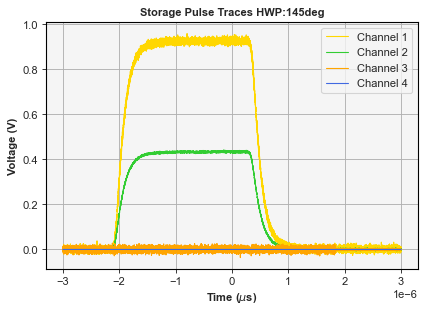

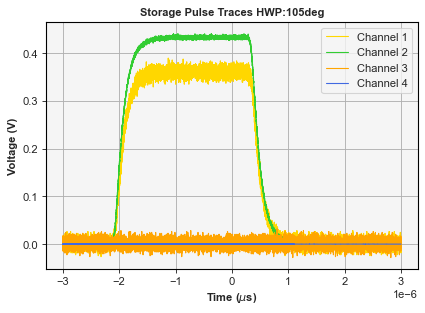

In [6]:
for index in index_1550_abs:
    plot_scope(ref_1550_time_data[index], [ref_1550_1550_pulse_data[index], ref_1550_1550_ref_data[index], ref_1550_995_pulse_data[index], ref_1550_995_ref_data[index]])
    mp.title('Storage Pulse Traces' + ' HWP:' + polarisations_1550[index] + 'deg')

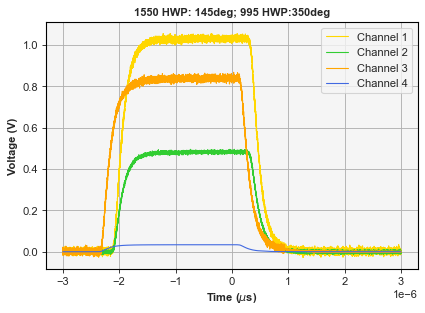

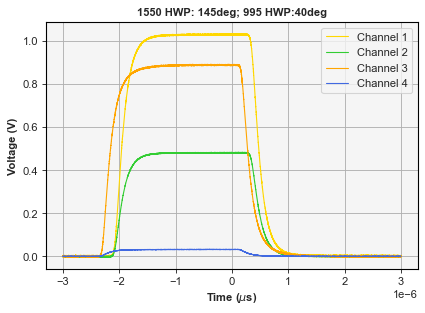

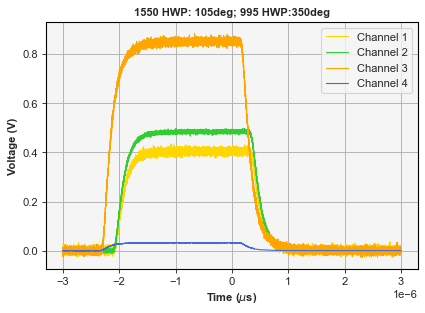

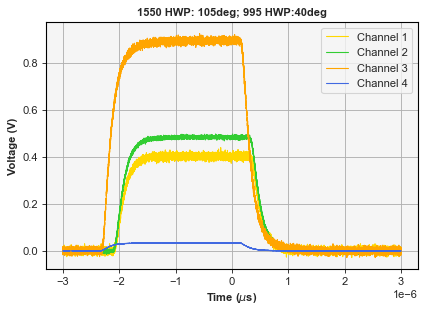

In [7]:
for pol_1550 in index_1550_fix_abs:
    for pol_995 in index_995_abs:
        plot_scope(tpa_time_data_1550_fix[pol_1550][pol_995], [tpa_1550_pulse_data_1550_fix[pol_1550][pol_995], tpa_1550_ref_data_1550_fix[pol_1550][pol_995], tpa_995_pulse_data_1550_fix[pol_1550][pol_995], tpa_995_ref_data_1550_fix[pol_1550][pol_995]])
        mp.title('1550 HWP: ' + polarisation_1550[pol_1550] + 'deg' + '; 995 HWP:' + polarisations_995[pol_995] + 'deg')

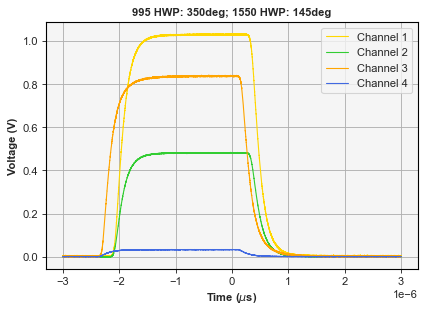

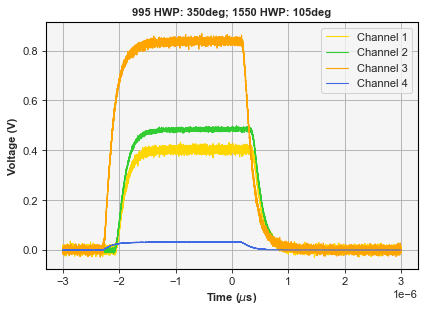

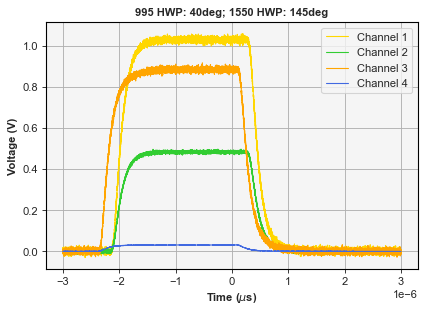

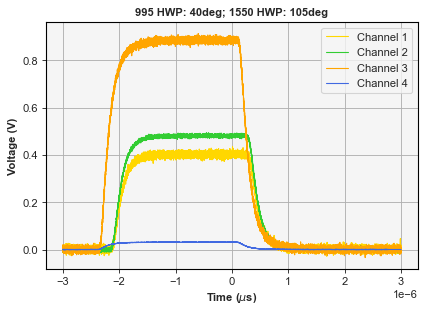

In [8]:
for pol_995 in index_995_fix_abs:
    for pol_1550 in index_1550_abs:
        plot_scope(tpa_time_data_995_fix[pol_995][pol_1550], [tpa_1550_pulse_data_995_fix[pol_995][pol_1550], tpa_1550_ref_data_995_fix[pol_995][pol_1550], tpa_995_pulse_data_995_fix[pol_995][pol_1550], tpa_995_ref_data_995_fix[pol_995][pol_1550]])
        mp.title('995 HWP: ' + polarisation_995[pol_995] + 'deg' + '; 1550 HWP: ' + polarisations_1550[pol_1550] + 'deg')


##### Normalise pulse data & determine area
        
        Subtract background counts from pulses and divide by references (where avaliable) and calculate area of normalised pulse data


In [9]:
# normalised storage pulse transmission when 1550 polarisation is fixed
norm_sp_1550_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_1550_pulse_data_1550_fix[fix_pol], ref_995_1550_pulse_data, tpa_1550_ref_data_1550_fix[fix_pol])] for fix_pol in index_1550_fix_abs]
area_sp_1550 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_sp_1550_fix, tpa_time_data_1550_fix)]
# normalised control pulse transmission when 1550 polarisation is fixed 
norm_cp_1550_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_995_pulse_data_1550_fix[fix_pol], ref_1550_995_pulse_data[pol], tpa_995_ref_data_1550_fix[fix_pol])] for fix_pol, pol in zip(index_1550_fix_abs, index_1550_abs)]
area_cp_1550 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_cp_1550_fix, tpa_time_data_1550_fix)]
# normalised storage pulse transmission when 995 polarisation is fixed
norm_sp_995_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_1550_pulse_data_995_fix[fix_pol], ref_995_1550_pulse_data[pol], tpa_1550_ref_data_995_fix[fix_pol])] for fix_pol, pol in zip(index_995_fix_abs, index_1550_abs)]
area_sp_995 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_sp_995_fix, tpa_time_data_995_fix)]
# normalised control pulse transmission when 995 polarisation is fixed
norm_cp_995_fix = [[normalise(pulse, leakage, ref) for pulse, leakage, ref in zip(tpa_995_pulse_data_995_fix[fix_pol], ref_1550_995_pulse_data, tpa_995_ref_data_995_fix[fix_pol])] for fix_pol in index_995_fix_abs]
area_cp_995 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_cp_995_fix, tpa_time_data_995_fix)]
# normalised sp reference for OD calc
norm_sp = [transmitted/reflected for transmitted, reflected in zip(ref_1550_1550_pulse_data, ref_1550_1550_ref_data)]
norm_cp = [transmitted/reflected for transmitted, reflected in zip(ref_995_995_pulse_data, ref_995_995_ref_data)]
# OD calc for 995 fixed and sweep 1550
OD_sp_995_fix = [[OD_calc(ref, trans) for ref, trans in zip(norm_sp, trans_data)] for trans_data in norm_sp_995_fix]
OD_cp_1550_fix = [[OD_calc(ref, trans) for ref, trans in zip(norm_cp, trans_data)] for trans_data in norm_cp_1550_fix]


##### Plot Similar Signals Together
        
        Check effect of polarisation between references and TPA data


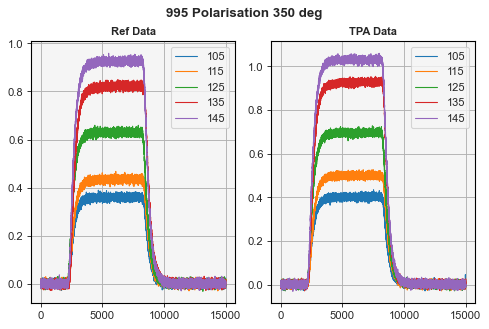

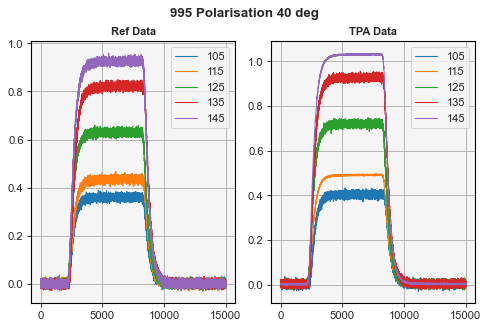

In [115]:
for index, fix_pol in enumerate(index_995_fix_abs):
    fig, ax = mp.subplots(1, 2, constrained_layout=True)
    fig.suptitle(f'995 Polarisation {polarisation_995[fix_pol]} deg')
    count = 0
    for ref_data, tpa_data in zip(ref_1550_1550_pulse_data, tpa_1550_pulse_data_995_fix[index]):
        ax[0].set(title=('Ref Data'))
        ax[0].plot(ref_data, label=polarisations_1550[count])
        ax[0].legend(loc='best')
        ax[1].set(title=('TPA Data'))
        ax[1].plot(tpa_data, label=polarisations_1550[count])
        ax[1].legend(loc='best')
        count += 1

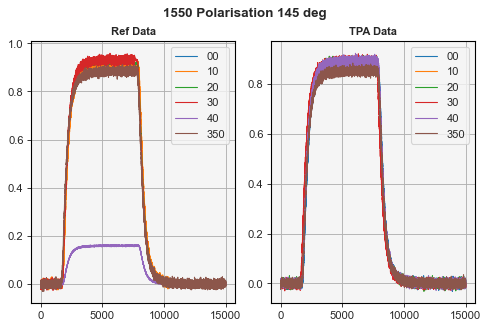

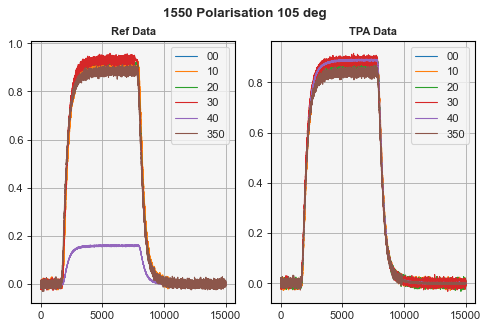

In [116]:
for index, fix_pol in enumerate(index_1550_fix_abs):
    fig, ax = mp.subplots(1, 2, constrained_layout=True)
    fig.suptitle(f'1550 Polarisation {polarisation_1550[fix_pol]} deg')
    count = 0
    for ref_data, tpa_data in zip(ref_995_995_pulse_data, tpa_995_pulse_data_1550_fix[index]):
        ax[0].set(title=('Ref Data'))
        ax[0].plot(ref_data, label=polarisations_995[count])
        ax[0].legend(loc='best')
        ax[1].set(title=('TPA Data'))
        ax[1].plot(tpa_data, label=polarisations_995[count])
        ax[1].legend(loc='best')
        count += 1

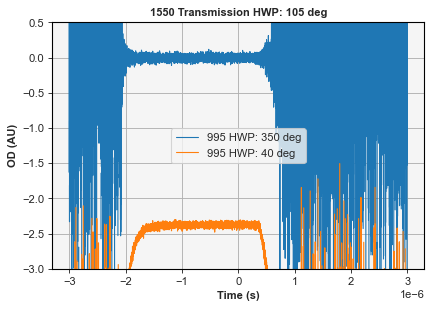

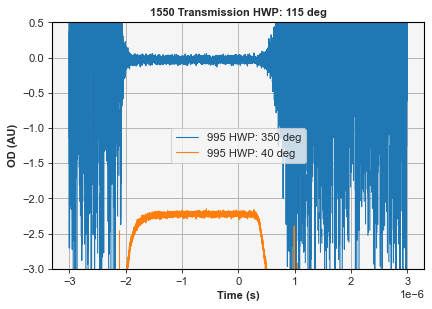

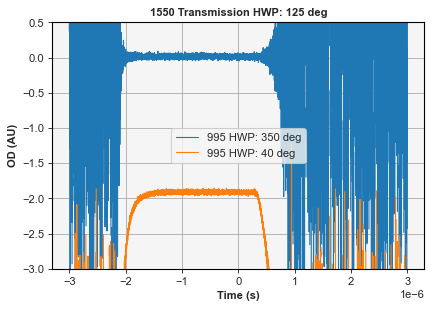

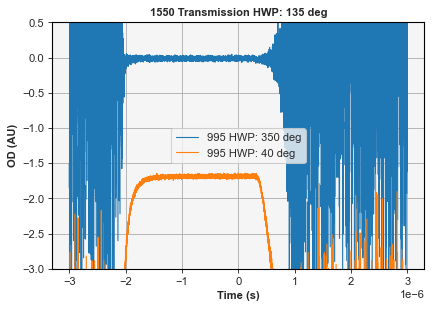

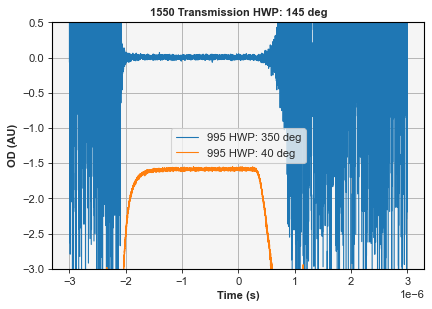

In [117]:
for index, value in enumerate(polarisations_1550):
    mp.figure()
    mp.plot(tpa_time_data_995_fix[min_995_fix_abs][index], OD_sp_995_fix[min_995_fix_abs][index], label=f'995 HWP: {polarisations_995[min_995_abs]} deg')
    mp.plot(tpa_time_data_995_fix[max_995_fix_abs][index], OD_sp_995_fix[max_995_fix_abs][index], label=f'995 HWP: {polarisations_995[max_995_abs]} deg')
    ax_1 = mp.gca()
    ax_1.set(ylim=(-3, 0.5))
    ax_1.set(xlabel='Time (s)', ylabel='OD (AU)')
    ax_1.legend(loc='best')
    ax_1.set(title=f'1550 Transmission HWP: {value} deg')

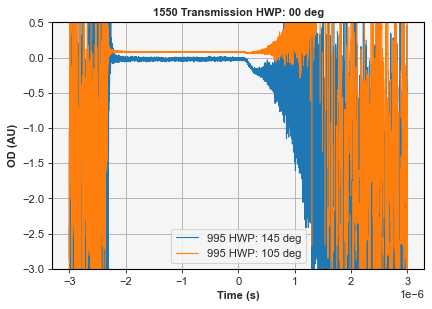

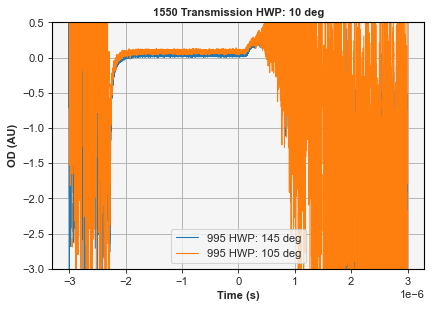

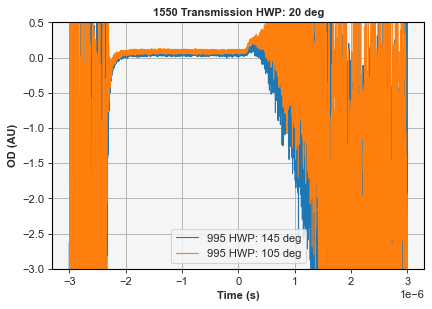

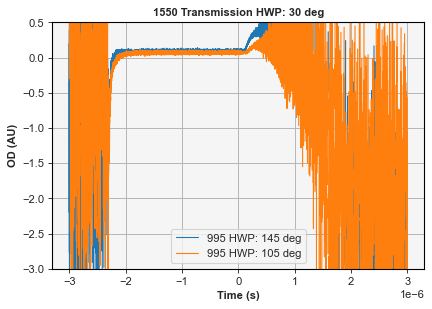

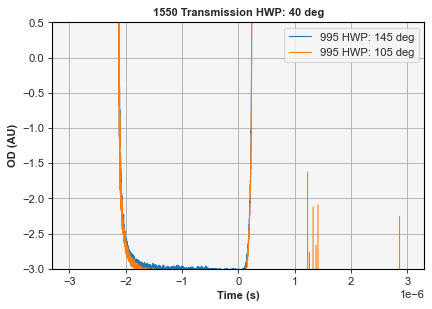

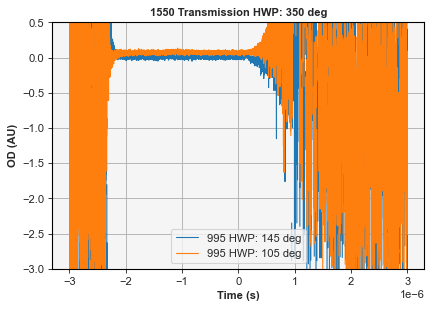

In [118]:
for index, value in enumerate(polarisations_995):
    mp.figure()
    mp.plot(tpa_time_data_1550_fix[min_1550_fix_abs][index], OD_cp_1550_fix[min_1550_fix_abs][index], label=f'995 HWP: {polarisations_1550[min_1550_abs]} deg')
    mp.plot(tpa_time_data_1550_fix[max_1550_fix_abs][index], OD_cp_1550_fix[max_1550_fix_abs][index], label=f'995 HWP: {polarisations_1550[max_1550_abs]} deg')
    ax_1 = mp.gca()
    ax_1.set(ylim=(-3, 0.5))
    ax_1.set(xlabel='Time (s)', ylabel='OD (AU)')
    ax_1.legend(loc='best')
    ax_1.set(title=f'1550 Transmission HWP: {value} deg')


##### Plot normalised transmission data
        
        Plot various transmission data on top of each other to look for absorption

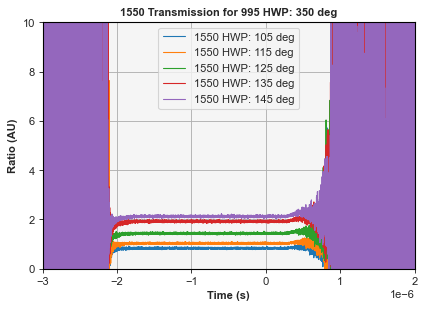

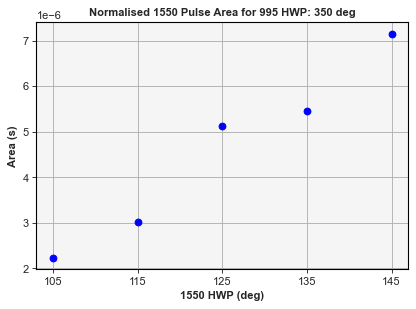

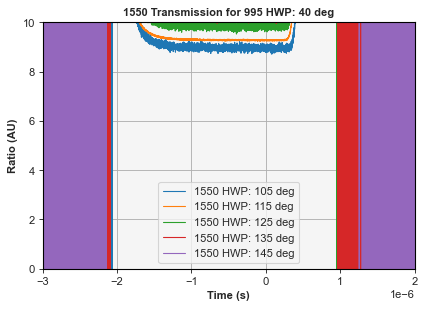

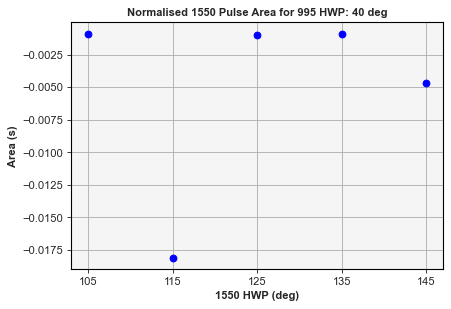

In [11]:
for fix_pol in index_995_fix_abs:
    mp.figure()
    index = 0
    for time, values in zip(tpa_time_data_995_fix[fix_pol], norm_sp_995_fix[fix_pol]):
        mp.plot(time, values, label=f'1550 HWP: {polarisations_1550[index]} deg')
        ax_1 = mp.gca()
        ax_1.set(xlim=(-3E-6, 2E-6), ylim=(0, 10))
        ax_1.set(xlabel='Time (s)', ylabel='Ratio (AU)')
        ax_1.legend(loc='best')
        ax_1.set(title=f'1550 Transmission for 995 HWP: {polarisation_995[fix_pol]} deg')
        index += 1

    mp.figure()
    for label, values in zip(polarisations_1550, area_sp_995[fix_pol]):
        mp.plot(label, values, 'bo')
        ax_2 = mp.gca()
        ax_2.set(xlabel='1550 HWP (deg)', ylabel='Area (s)')
        ax_2.set(title=f'Normalised 1550 Pulse Area for 995 HWP: {polarisation_995[fix_pol]} deg')

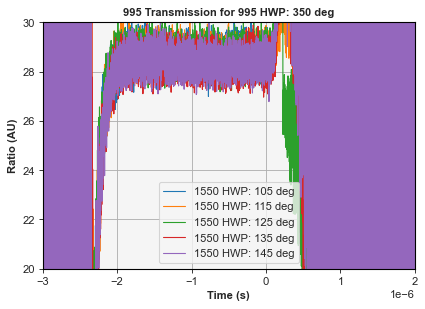

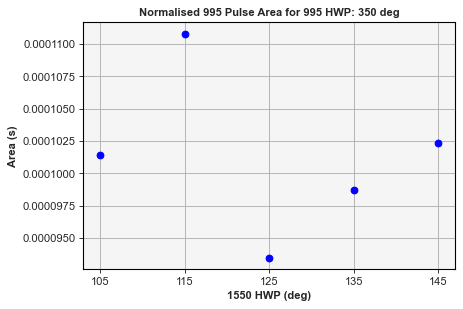

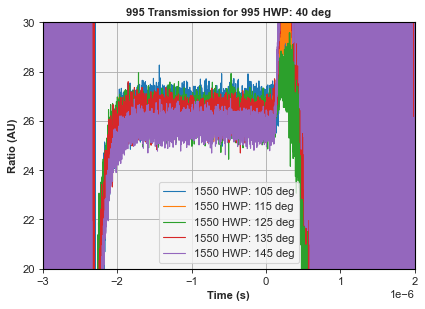

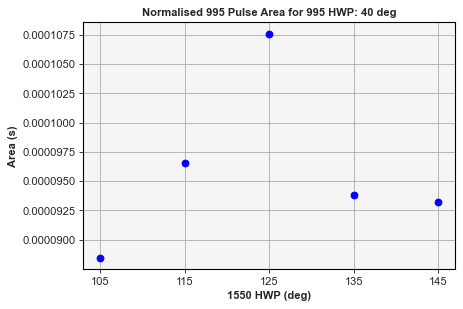

In [92]:
for fix_pol in index_995_fix_abs:
    mp.figure()
    index = 0
    for time, values in zip(tpa_time_data_995_fix[fix_pol], norm_cp_995_fix[fix_pol]):
        mp.plot(time, values, label=f'1550 HWP: {polarisations_1550[index]} deg')
        ax = mp.gca()
        ax.set(xlim=(-3E-6, 2E-6), ylim=(20, 30))
        ax.set(xlabel='Time (s)', ylabel='Ratio (AU)')
        ax.legend(loc='best', frameon=True)
        ax.set(title=f'995 Transmission for 995 HWP: {polarisation_995[fix_pol]} deg')
        index += 1

    mp.figure()
    for label, values in zip(polarisations_1550, area_cp_995[fix_pol]):
        mp.plot(label, values, 'bo')
        ax_2 = mp.gca()
        ax_2.set(xlabel='1550 HWP (deg)', ylabel='Area (s)')
        ax_2.set(title=f'Normalised 995 Pulse Area for 995 HWP: {polarisation_995[fix_pol]} deg')

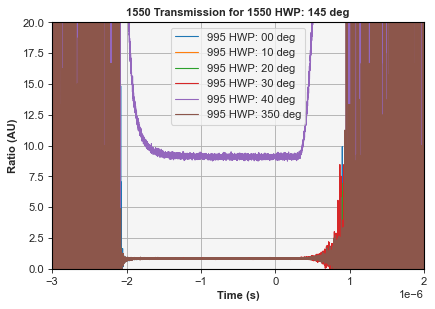

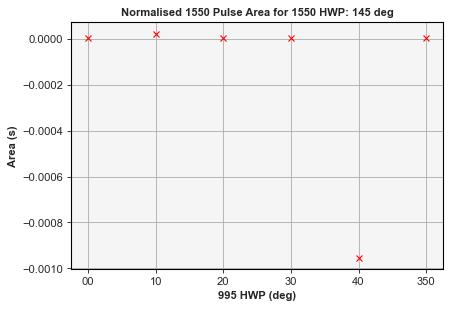

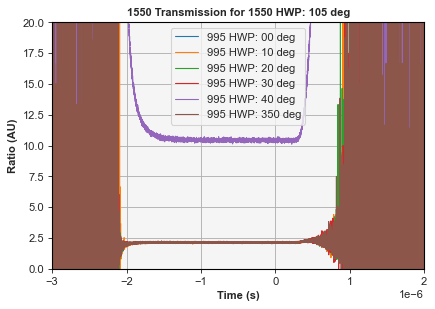

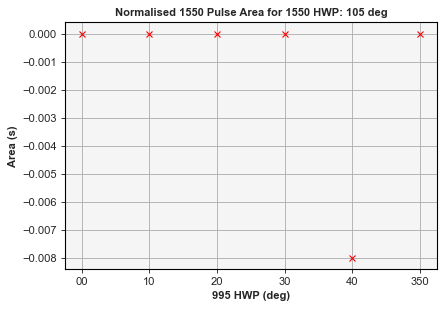

In [13]:
for fix_pol in index_1550_fix_abs:
    mp.figure()
    index = 0
    for time, values in zip(tpa_time_data_1550_fix[fix_pol], norm_sp_1550_fix[fix_pol]):
        mp.plot(time, values, label=f'995 HWP: {polarisations_995[index]} deg')
        ax = mp.gca()
        ax.set(xlim=(-3E-6, 2E-6), ylim=(0, 20))
        ax.set(xlabel='Time (s)', ylabel='Ratio (AU)')
        ax.legend(loc='best', frameon=True)
        ax.set(title=f'1550 Transmission for 1550 HWP: {polarisation_1550[fix_pol]} deg')
        index += 1

    mp.figure()
    for label, values in zip(polarisations_995, area_sp_1550[fix_pol]):
        mp.plot(label, values, 'rx')
        ax_2 = mp.gca()
        ax_2.set(xlabel='995 HWP (deg)', ylabel='Area (s)')
        ax_2.set(title=f'Normalised 1550 Pulse Area for 1550 HWP: {polarisation_1550[fix_pol]} deg')

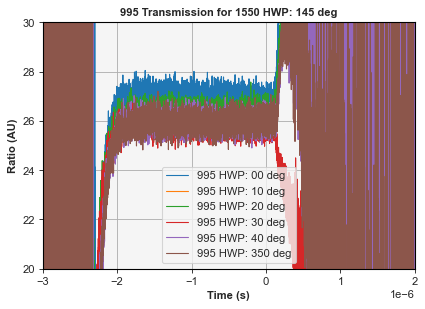

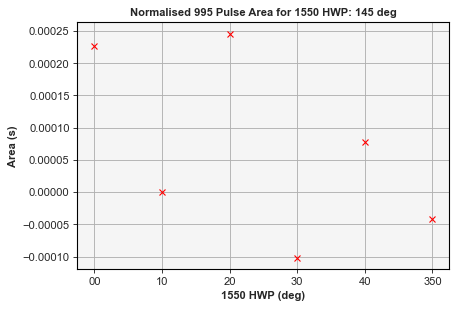

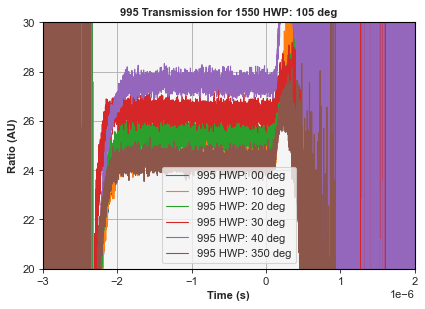

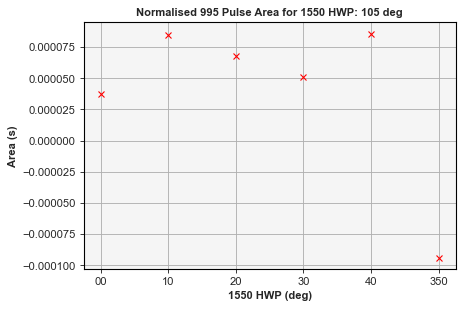

In [14]:
for fix_pol in index_1550_fix_abs:
    mp.figure()
    index = 0
    for time, values in zip(tpa_time_data_1550_fix[fix_pol], norm_cp_1550_fix[fix_pol]):
        mp.plot(time, values, label=f'995 HWP: {polarisations_995[index]} deg')
        ax = mp.gca()
        ax.set(xlim=(-3E-6, 2E-6), ylim=(20, 30))
        ax.set(xlabel='Time (s)', ylabel='Ratio (AU)')
        ax.legend(loc='best', frameon=True)
        ax.set(title=f'995 Transmission for 1550 HWP: {polarisation_1550[fix_pol]} deg')
        index += 1

    mp.figure()
    for label, values in zip(polarisations_995, area_cp_1550[fix_pol]):
        mp.plot(label, values, 'rx')
        ax_2 = mp.gca()
        ax_2.set(xlabel='1550 HWP (deg)', ylabel='Area (s)')
        ax_2.set(title=f'Normalised 995 Pulse Area for 1550 HWP: {polarisation_1550[fix_pol]} deg')

In [15]:
# normalised storage pulse transmission when 1550 polarisation is fixed
norm_sp_1550_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_1550_pulse_data_1550_fix[fix_pol], ref_995_1550_pulse_data, tpa_1550_ref_data_1550_fix[fix_pol])] for fix_pol in index_1550_fix_abs]
area_sp_1550 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_sp_1550_fix, tpa_time_data_1550_fix)]
# normalised control pulse transmission when 1550 polarisation is fixed 
norm_cp_1550_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_995_pulse_data_1550_fix[fix_pol], ref_1550_995_pulse_data[pol], tpa_995_ref_data_1550_fix[fix_pol])] for fix_pol, pol in zip(index_1550_fix_abs, index_1550_abs)]
area_cp_1550 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_cp_1550_fix, tpa_time_data_1550_fix)]
# normalised storage pulse transmission when 995 polarisation is fixed
norm_sp_995_fix = [[normalise(trans, leakage, ref) for trans, leakage, ref in zip(tpa_1550_pulse_data_995_fix[fix_pol], ref_995_1550_pulse_data[pol], tpa_1550_ref_data_995_fix[fix_pol])] for fix_pol, pol in zip(index_995_fix_abs, index_1550_abs)]
area_sp_995 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_sp_995_fix, tpa_time_data_995_fix)]
# normalised control pulse transmission when 995 polarisation is fixed
norm_cp_995_fix = [[normalise(pulse, leakage, ref) for pulse, leakage, ref in zip(tpa_995_pulse_data_995_fix[fix_pol], ref_1550_995_pulse_data, tpa_995_ref_data_995_fix[fix_pol])] for fix_pol in index_995_fix_abs]
area_cp_995 = [[simpson(trans, time) for trans, time in zip(trans_fix, time_fix)] for trans_fix, time_fix in zip(norm_cp_995_fix, tpa_time_data_995_fix)]